In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

In [15]:
usuarios_activos = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_actualizado.csv')
usuarios_eliminados = pd.read_csv('drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_actualizado.csv')

In [9]:
usuarios_eliminados.to_csv('drive/MyDrive/ColabNotebooks/Business_Payments/test_usuarios_eliminados.csv', index=False)

In [ ]:
usuarios_activos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29522 entries, 0 to 29521
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       29522 non-null  int64  
 1   amount                                   29522 non-null  float64
 2   status                                   29522 non-null  object 
 3   created_at                               29522 non-null  object 
 4   updated_at                               29522 non-null  object 
 5   user_id                                  29522 non-null  float64
 6   moderated_at                             19434 non-null  object 
 7   reimbursement_date                       29522 non-null  object 
 8   cash_request_received_date               22988 non-null  object 
 9   money_back_date                          22750 non-null  object 
 10  transfer_type                            29522

In [ ]:
usuarios_eliminados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2573 entries, 0 to 2572
Data columns (total 39 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       2573 non-null   int64  
 1   amount                                   2573 non-null   float64
 2   status                                   2573 non-null   object 
 3   created_at                               2573 non-null   object 
 4   updated_at                               2573 non-null   object 
 5   moderated_at                             2326 non-null   object 
 6   deleted_account_id                       2573 non-null   float64
 7   reimbursement_date                       2573 non-null   object 
 8   cash_request_received_date               1162 non-null   object 
 9   money_back_date                          1168 non-null   object 
 10  transfer_type                            2573 no

In [ ]:
usuarios_activos["created_at"].min()

Timestamp('2019-11-19 13:57:53.511561')

In [16]:
import pandas as pd

# Lista de columnas de fechas en los datasets
columnas_fechas = [
    "created_at", "updated_at", "paid_at", "from_date", "to_date",
    "created_at_fees", "updated_at_fees", "paid_at_fees",
    "cash_request_created_at", "cash_request_updated_at",
    "reimbursement_date", "cash_request_received_date",
    "money_back_date", "send_at", "moderated_at"
]

# Función para convertir fechas eliminando la zona horaria
def convertir_fechas_sin_zona_horaria(df, columnas_fechas):
    for col in columnas_fechas:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce").dt.tz_localize(None)
    return df

# Aplicar la conversión a ambos datasets
usuarios_activos = convertir_fechas_sin_zona_horaria(usuarios_activos, columnas_fechas)
usuarios_eliminados = convertir_fechas_sin_zona_horaria(usuarios_eliminados, columnas_fechas)




In [17]:
usuarios_activos["cohorte_primer_solicitud"] = usuarios_activos.groupby("user_id")["created_at"].transform("min").dt.to_period("M")
usuarios_eliminados["cohorte_primer_solicitud"] = usuarios_eliminados.groupby("deleted_account_id")["created_at"].transform("min").dt.to_period("M")

In [18]:
# Crear las columnas necesarias en ambos datasets
for df, user_col in zip([usuarios_activos, usuarios_eliminados], ["user_id", "deleted_account_id"]):
    # Contar total de compras por usuario
    df["total_compras"] = df.groupby(user_col)["id"].transform("count")

    # Sumar el monto total gastado por usuario
    df["monto_total"] = df.groupby(user_col)["amount"].transform("sum")

    # Eliminar duplicados para que cada usuario tenga solo una fila
    df.drop_duplicates(subset=[user_col], inplace=True)

# Verificar que las columnas fueron creadas correctamente
print(usuarios_activos[[ "user_id", "total_compras", "monto_total"]].head())
print(usuarios_eliminados[["deleted_account_id", "total_compras", "monto_total"]].head())


   user_id  total_compras  monto_total
0    804.0              1        100.0
1    231.0             10       1000.0
2    191.0              2        200.0
3    761.0              1         99.0
4   7686.0              1        100.0
   deleted_account_id  total_compras  monto_total
0               309.0              2        200.0
1              2499.0              1        100.0
2               304.0              2        200.0
4                91.0              1        100.0
5               575.0              3        299.0


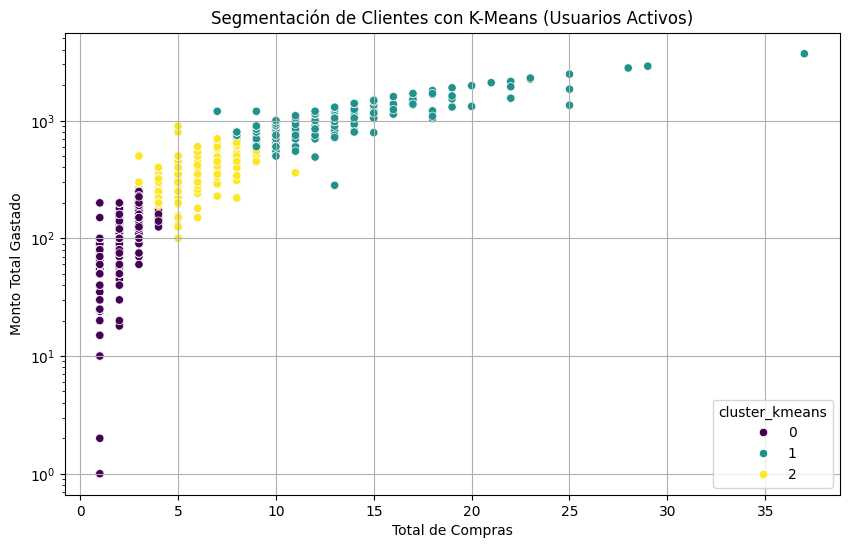

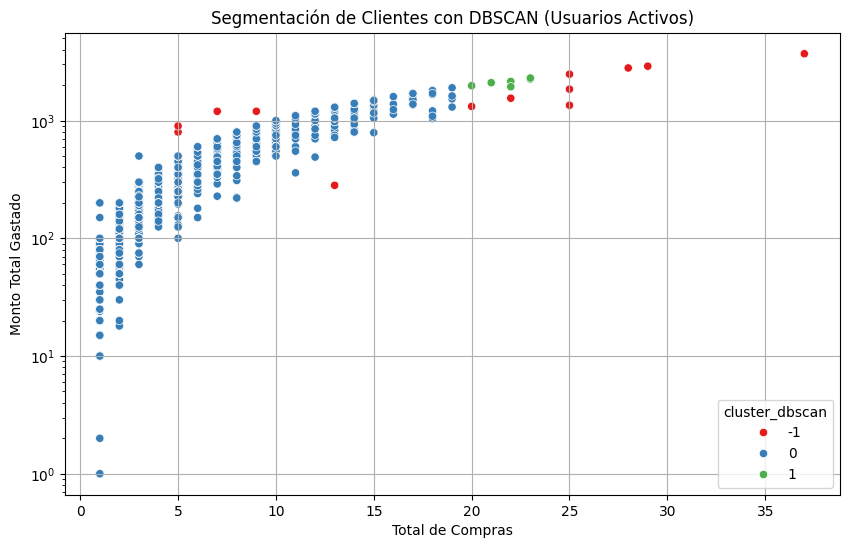

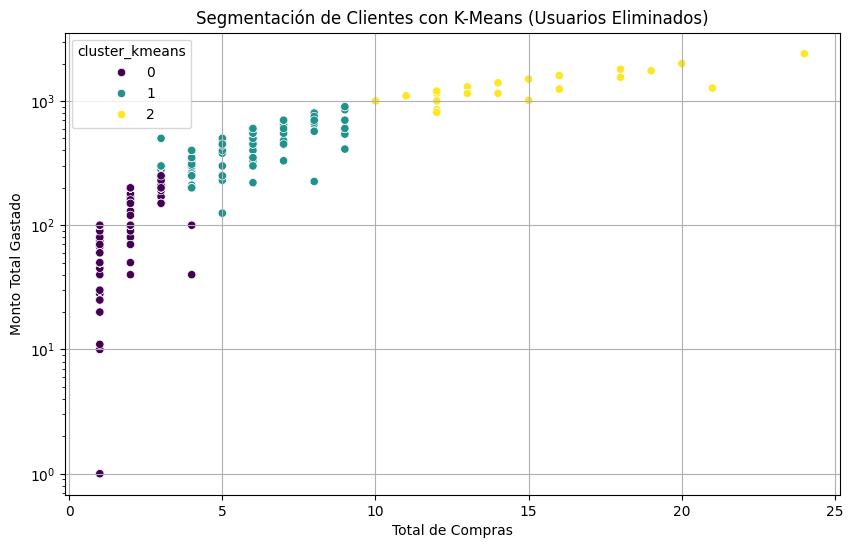

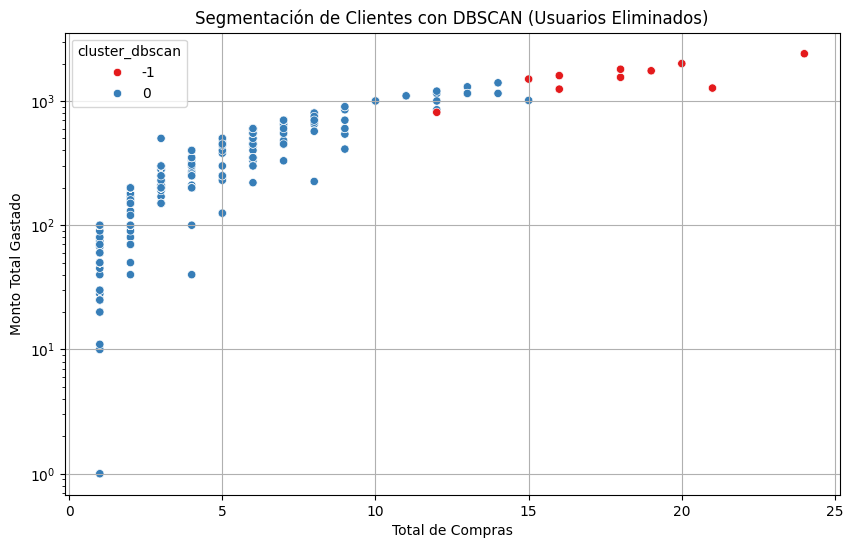

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# Función para procesar los datos y aplicar clusterización
def segmentar_clientes(df, titulo):
    # Seleccionar características para la clusterización
    X = df[["total_compras", "monto_total"]].copy()

    # Escalar los datos para mejor normalización
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Aplicar K-Means con 3 clusters
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

    # Aplicar DBSCAN
    dbscan = DBSCAN(eps=0.8, min_samples=5)  # Ajustar parámetros según datos
    df["cluster_dbscan"] = dbscan.fit_predict(X_scaled)

    # Gráfico K-Means
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df["total_compras"], y=df["monto_total"], hue=df["cluster_kmeans"], palette="viridis")
    plt.xlabel("Total de Compras")
    plt.ylabel("Monto Total Gastado")
    plt.title(f"Segmentación de Clientes con K-Means ({titulo})")
    plt.yscale("log")  # Mejor visualización si hay valores dispersos
    plt.grid(True)
    plt.show()

    # Gráfico DBSCAN
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df["total_compras"], y=df["monto_total"], hue=df["cluster_dbscan"], palette="Set1")
    plt.xlabel("Total de Compras")
    plt.ylabel("Monto Total Gastado")
    plt.title(f"Segmentación de Clientes con DBSCAN ({titulo})")
    plt.yscale("log")
    plt.grid(True)
    plt.show()

# Aplicar segmentación en ambos datasets
segmentar_clientes(usuarios_activos, "Usuarios Activos")
segmentar_clientes(usuarios_eliminados, "Usuarios Eliminados")

Segmentación con K-Means (Usuarios Activos vs. Eliminados)
📊 Patrón observado:

Se identifican tres clusters en ambos grupos:
Cluster 0 (morado): Clientes con bajas compras y bajo gasto.
Cluster 1 (verde/azul): Clientes con más compras y mayor gasto.
Cluster 2 (amarillo): Clientes de alto valor, con más compras y gastos significativamente altos.
🔹 Comparación entre usuarios activos y eliminados:

La distribución de usuarios activos muestra una mayor presencia en los clusters de compras recurrentes (verde/azul).
En cambio, en usuarios eliminados, el cluster de clientes de alto valor (amarillo) sigue presente, pero hay una menor densidad en compras recurrentes.
Esto sugiere que los clientes eliminados tienden a concentrarse en extremos: usuarios de bajo valor o de alto valor.

In [21]:
usuarios_activos.to_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv", index=False)
usuarios_eliminados.to_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv", index=False)


In [3]:

# 📌 1️⃣ Cargar los datasets
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

In [23]:
!pip install imbalanced-learn


In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


# 📌 2️⃣ Convertir variables numéricas que pueden estar en formato string
cols_numericas = ["total_compras", "monto_total", "tasa_rechazo", "intervalo_promedio_solicitudes", "pago_tardio_ratio"]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 📌 3️⃣ Crear la variable objetivo 'status' (1 = eliminado, 0 = activo)
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# 📌 4️⃣ Unificar ambos datasets en un solo DataFrame
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# 📌 5️⃣ Seleccionar las características relevantes
features = ["total_compras", "monto_total", "tasa_rechazo", "intervalo_promedio_solicitudes", "pago_tardio_ratio"]
X = df_usuarios[features].fillna(0)  # Rellenar posibles valores nulos con 0
y = df_usuarios["status"]

# 📌 6️⃣ Normalizar las variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 📌 7️⃣ Separar datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

# 📌 8️⃣ Entrenar el modelo de Regresión Logística
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

# 📌 9️⃣ Realizar predicciones en el conjunto de prueba
y_pred = log_reg.predict(X_test)
y_pred_prob = log_reg.predict_proba(X_test)[:, 1]

# 📌 🔟 Evaluar el modelo
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

# 📌 🔹 Mostrar Resultados
print(f"🔹 Precisión del Modelo: {accuracy:.4f}")
print("\n🔹 Matriz de Confusión:")
print(conf_matrix)
print("\n🔹 Reporte de Clasificación:")
print(class_report)


🔹 Precisión del Modelo: 0.9045

🔹 Matriz de Confusión:
[[2160    0]
 [ 228    0]]

🔹 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      2160
           1       0.00      0.00      0.00       228

    accuracy                           0.90      2388
   macro avg       0.45      0.50      0.47      2388
weighted avg       0.82      0.90      0.86      2388



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# 📌 1️⃣ Cargar los datasets
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# 📌 2️⃣ Convertir variables numéricas que pueden estar en formato string
cols_numericas = ["total_compras", "monto_total", "tasa_rechazo", "intervalo_promedio_solicitudes", "pago_tardio_ratio"]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 📌 3️⃣ Crear la variable objetivo 'status' (1 = eliminado, 0 = activo)
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# 📌 4️⃣ Unificar ambos datasets en un solo DataFrame
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# 📌 5️⃣ Seleccionar las características relevantes
features = ["total_compras", "monto_total", "tasa_rechazo", "intervalo_promedio_solicitudes", "pago_tardio_ratio"]
X = df_usuarios[features].fillna(0)  # Rellenar posibles valores nulos con 0
y = df_usuarios["status"]

# 📌 6️⃣ Normalizar las variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 📌 7️⃣ Aplicar SMOTE para balancear las clases
smote = SMOTE(sampling_strategy=0.5, random_state=42)  # Ajustamos para que la clase 1 tenga el 50% de la clase 0
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# 📌 8️⃣ Separar datos en entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

# 📌 9️⃣ Entrenar el modelo de Regresión Logística con los datos balanceados
log_reg_smote = LogisticRegression()
log_reg_smote.fit(X_train, y_train)

# 📌 🔟 Realizar predicciones en el conjunto de prueba
y_pred_smote = log_reg_smote.predict(X_test)
y_pred_prob_smote = log_reg_smote.predict_proba(X_test)[:, 1]

# 📌 Evaluar el modelo después de aplicar SMOTE
accuracy_smote = accuracy_score(y_test, y_pred_smote)
conf_matrix_smote = confusion_matrix(y_test, y_pred_smote)
class_report_smote = classification_report(y_test, y_pred_smote)

# 📌 🔹 Mostrar Resultados
print(f"🔹 Precisión del Modelo después de SMOTE: {accuracy_smote:.4f}")
print("\n🔹 Matriz de Confusión:")
print(conf_matrix_smote)
print("\n🔹 Reporte de Clasificación:")
print(class_report_smote)


🔹 Precisión del Modelo después de SMOTE: 0.8025

🔹 Matriz de Confusión:
[[1918  242]
 [ 398  682]]

🔹 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      2160
           1       0.74      0.63      0.68      1080

    accuracy                           0.80      3240
   macro avg       0.78      0.76      0.77      3240
weighted avg       0.80      0.80      0.80      3240



In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# 📌 1️⃣ Cargar los datasets
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# 📌 2️⃣ Convertir variables numéricas
cols_numericas = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 📌 3️⃣ Crear la variable objetivo 'status' (1 = eliminado, 0 = activo)
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# 📌 4️⃣ Unificar ambos datasets
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# 📌 5️⃣ Seleccionar variables predictivas (incluyendo nuevas variables)
features_extra = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]
X_extra = df_usuarios[features_extra].fillna(0)
y_extra = df_usuarios["status"]

# 📌 6️⃣ Normalizar variables
scaler_extra = StandardScaler()
X_scaled_extra = scaler_extra.fit_transform(X_extra)

# 📌 7️⃣ Aplicar SMOTE para balancear las clases
smote = SMOTE(sampling_strategy=0.5, random_state=42)  # 50% de la clase mayoritaria
X_resampled_extra, y_resampled_extra = smote.fit_resample(X_scaled_extra, y_extra)

# 📌 8️⃣ Separar datos en entrenamiento y prueba (80% - 20%)
X_train_extra, X_test_extra, y_train_extra, y_test_extra = train_test_split(
    X_resampled_extra, y_resampled_extra, test_size=0.2, random_state=42, stratify=y_resampled_extra
)

# 📌 9️⃣ Optimización de Hiperparámetros en Regresión Logística
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],  # Regularización
    "penalty": ["l2"],  # Solo L2 para estabilidad
    "solver": ["liblinear", "lbfgs"]  # Probar diferentes optimizadores
}

log_reg_opt = LogisticRegression()
grid_search = GridSearchCV(log_reg_opt, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train_extra, y_train_extra)

# 📌 🔟 Evaluación del Mejor Modelo Encontrado
best_model = grid_search.best_estimator_

# Predicciones
y_pred_opt = best_model.predict(X_test_extra)
y_pred_prob_opt = best_model.predict_proba(X_test_extra)[:, 1]

# 📌 Evaluación del modelo optimizado
accuracy_opt = accuracy_score(y_test_extra, y_pred_opt)
conf_matrix_opt = confusion_matrix(y_test_extra, y_pred_opt)
class_report_opt = classification_report(y_test_extra, y_pred_opt)

# 📌 🔹 Mostrar Resultados
print(f"🔹 Mejores Hiperparámetros: {grid_search.best_params_}")
print(f"🔹 Precisión del Modelo Optimizado: {accuracy_opt:.4f}")
print("\n🔹 Matriz de Confusión:")
print(conf_matrix_opt)
print("\n🔹 Reporte de Clasificación:")
print(class_report_opt)


🔹 Mejores Hiperparámetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
🔹 Precisión del Modelo Optimizado: 0.8022

🔹 Matriz de Confusión:
[[1917  243]
 [ 398  682]]

🔹 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      2160
           1       0.74      0.63      0.68      1080

    accuracy                           0.80      3240
   macro avg       0.78      0.76      0.77      3240
weighted avg       0.80      0.80      0.80      3240



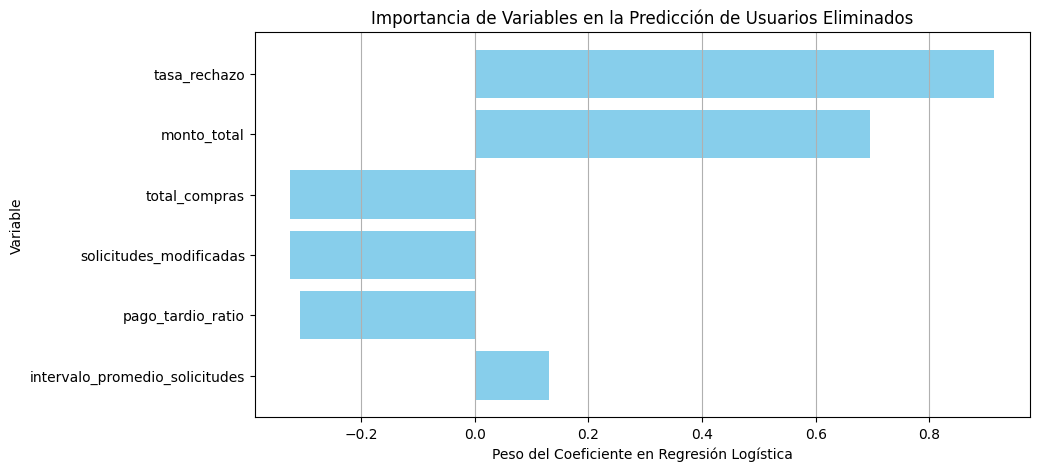

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE

# 📌 1️⃣ Cargar los datasets
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# 📌 2️⃣ Convertir variables numéricas
cols_numericas = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]

for df in [usuarios_activos, usuarios_eliminados]:
    for col in cols_numericas:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 📌 3️⃣ Crear la variable objetivo 'status' (1 = eliminado, 0 = activo)
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# 📌 4️⃣ Unificar ambos datasets
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# 📌 5️⃣ Seleccionar variables predictivas
features_extra = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]
X_extra = df_usuarios[features_extra].fillna(0)
y_extra = df_usuarios["status"]

# 📌 6️⃣ Normalizar variables
scaler_extra = StandardScaler()
X_scaled_extra = scaler_extra.fit_transform(X_extra)

# 📌 7️⃣ Aplicar SMOTE para balancear las clases
smote = SMOTE(sampling_strategy=0.5, random_state=42)
X_resampled_extra, y_resampled_extra = smote.fit_resample(X_scaled_extra, y_extra)

# 📌 8️⃣ Separar datos en entrenamiento y prueba (80% - 20%)
X_train_extra, X_test_extra, y_train_extra, y_test_extra = train_test_split(
    X_resampled_extra, y_resampled_extra, test_size=0.2, random_state=42, stratify=y_resampled_extra
)

# 📌 9️⃣ Entrenar el modelo de Regresión Logística con los mejores hiperparámetros
log_reg_opt = LogisticRegression(C=0.1, penalty="l2", solver="liblinear")
log_reg_opt.fit(X_train_extra, y_train_extra)

# 📌 🔟 Obtener coeficientes del modelo optimizado
feature_importance = log_reg_opt.coef_[0]

# 📌 🔹 Asociar coeficientes con nombres de variables
importance_df = pd.DataFrame({"Variable": features_extra, "Importancia": feature_importance})

# 📌 🔹 Ordenar por importancia absoluta
importance_df["Importancia_Abs"] = np.abs(importance_df["Importancia"])
importance_df = importance_df.sort_values(by="Importancia_Abs", ascending=False)

# 📌 📊 Gráfico de importancia de variables
plt.figure(figsize=(10, 5))
plt.barh(importance_df["Variable"], importance_df["Importancia"], color="skyblue")
plt.xlabel("Peso del Coeficiente en Regresión Logística")
plt.ylabel("Variable")
plt.title("Importancia de Variables en la Predicción de Usuarios Eliminados")
plt.gca().invert_yaxis()  # Invertir eje para que la variable más importante esté arriba
plt.grid(axis="x")

# 📌 Mostrar gráfico
plt.show()


In [6]:
!pip uninstall -y xgboost scikit-learn imbalanced-learn mlxtend
!pip install --no-cache-dir scikit-learn==1.3.2 imbalanced-learn==0.13.0 mlxtend xgboost==1.7.4


Found existing installation: xgboost 1.7.4
Uninstalling xgboost-1.7.4:
  Successfully uninstalled xgboost-1.7.4
Found existing installation: scikit-learn 1.2.2
Uninstalling scikit-learn-1.2.2:
  Successfully uninstalled scikit-learn-1.2.2
Found existing installation: imbalanced-learn 0.13.0
Uninstalling imbalanced-learn-0.13.0:
  Successfully uninstalled imbalanced-learn-0.13.0
Found existing installation: mlxtend 0.23.4
Uninstalling mlxtend-0.23.4:
  Successfully uninstalled mlxtend-0.23.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 127.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 294.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 MB 179.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 263.9 MB/s eta 0:00:00


In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# 📌 1️⃣ Cargar los datasets procesados
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# 📌 2️⃣ Crear la variable objetivo 'status' (1 = eliminado, 0 = activo)
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# Unificar ambos datasets en un solo DataFrame
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# 📌 3️⃣ Selección de Variables Predictivas
features_xgb = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]

# Convertir a valores numéricos (por si hay strings)
for col in features_xgb:
    df_usuarios[col] = pd.to_numeric(df_usuarios[col], errors="coerce")

# Seleccionar variables y objetivo
X_xgb = df_usuarios[features_xgb].fillna(0)  # Rellenar valores NaN con 0
y_xgb = df_usuarios["status"]

# 📌 4️⃣ Normalizar las variables numéricas
scaler_xgb = StandardScaler()
X_scaled_xgb = scaler_xgb.fit_transform(X_xgb)

# 📌 5️⃣ Aplicar SMOTE para balancear clases
smote = SMOTE(sampling_strategy=0.5, random_state=42)  # Ajustamos a 50% de la clase mayoritaria
X_resampled_xgb, y_resampled_xgb = smote.fit_resample(X_scaled_xgb, y_xgb)

# 📌 6️⃣ Separar en entrenamiento y prueba (80% - 20%)
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_resampled_xgb, y_resampled_xgb, test_size=0.2, random_state=42, stratify=y_resampled_xgb
)

# 📌 7️⃣ Configurar hiperparámetros iniciales para XGBoost
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# 📌 8️⃣ Definir los Hiperparámetros a Ajustar
param_grid_xgb = {
    "n_estimators": [50, 100, 200],  # Número de árboles en el modelo
    "max_depth": [3, 5, 7],  # Profundidad máxima de cada árbol
    "learning_rate": [0.01, 0.1, 0.2],  # Tasa de aprendizaje
    "subsample": [0.8, 1.0],  # Proporción de datos usados en cada iteración
    "colsample_bytree": [0.8, 1.0]  # Proporción de columnas usadas en cada iteración
}

# 📌 9️⃣ Entrenar XGBoost con GridSearchCV
grid_search_xgb = GridSearchCV(
    xgb_model, param_grid_xgb, cv=StratifiedKFold(n_splits=5), scoring="accuracy", n_jobs=-1
)
grid_search_xgb.fit(X_train_xgb, y_train_xgb)

# 📌 🔟 Evaluar el Mejor Modelo Encontrado
best_xgb_model = grid_search_xgb.best_estimator_

# Predicciones con el mejor modelo
y_pred_xgb = best_xgb_model.predict(X_test_xgb)
y_pred_prob_xgb = best_xgb_model.predict_proba(X_test_xgb)[:, 1]

# 📌 1️⃣1️⃣ Evaluación del Modelo Optimizado
accuracy_xgb = accuracy_score(y_test_xgb, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)
class_report_xgb = classification_report(y_test_xgb, y_pred_xgb)

# 📌 1️⃣2️⃣ Mostrar Resultados
print(f"🔹 Mejores Hiperparámetros Encontrados: {grid_search_xgb.best_params_}")
print(f"🔹 Precisión del Modelo XGBoost: {accuracy_xgb:.4f}")
print("\n🔹 Matriz de Confusión:")
print(conf_matrix_xgb)
print("\n🔹 Reporte de Clasificación:")
print(class_report_xgb)


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


🔹 Mejores Hiperparámetros Encontrados: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
🔹 Precisión del Modelo XGBoost: 0.8302

🔹 Matriz de Confusión:
[[1938  222]
 [ 328  752]]

🔹 Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      2160
           1       0.77      0.70      0.73      1080

    accuracy                           0.83      3240
   macro avg       0.81      0.80      0.80      3240
weighted avg       0.83      0.83      0.83      3240



In [12]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# 📌 1️⃣ Cargar los datasets procesados
usuarios_activos = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_activos_procesado.csv")
usuarios_eliminados = pd.read_csv("drive/MyDrive/ColabNotebooks/Business_Payments/usuarios_eliminados_procesado.csv")

# 📌 2️⃣ Crear la variable objetivo 'status' (1 = eliminado, 0 = activo)
usuarios_activos["status"] = 0
usuarios_eliminados["status"] = 1

# Unificar ambos datasets en un solo DataFrame
df_usuarios = pd.concat([usuarios_activos, usuarios_eliminados], ignore_index=True)

# 📌 3️⃣ Selección de Variables Predictivas
features_xgb = [
    "total_compras", "monto_total", "tasa_rechazo",
    "intervalo_promedio_solicitudes", "pago_tardio_ratio", "solicitudes_modificadas"
]

# Convertir a valores numéricos (por si hay strings)
for col in features_xgb:
    df_usuarios[col] = pd.to_numeric(df_usuarios[col], errors="coerce")

# Seleccionar variables y objetivo
X_xgb = df_usuarios[features_xgb].fillna(0)  # Rellenar valores NaN con 0
y_xgb = df_usuarios["status"]

# 📌 4️⃣ Normalizar las variables numéricas
scaler_xgb = StandardScaler()
X_scaled_xgb = scaler_xgb.fit_transform(X_xgb)

# 📌 5️⃣ Aplicar SMOTE para balancear clases
smote = SMOTE(sampling_strategy=0.5, random_state=42)  # Ajustamos a 50% de la clase mayoritaria
X_resampled_xgb, y_resampled_xgb = smote.fit_resample(X_scaled_xgb, y_xgb)

# 📌 6️⃣ Separar en entrenamiento y prueba (80% - 20%)
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_resampled_xgb, y_resampled_xgb, test_size=0.2, random_state=42, stratify=y_resampled_xgb
)

# 📌 7️⃣ Configurar hiperparámetros iniciales para XGBoost
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

# 📌 8️⃣ Definir los Hiperparámetros a Ajustar
param_grid_xgb = {
    "n_estimators": [50, 100, 200],  # Número de árboles en el modelo
    "max_depth": [3, 5, 7],  # Profundidad máxima de cada árbol
    "learning_rate": [0.01, 0.1, 0.2],  # Tasa de aprendizaje
    "subsample": [0.8, 1.0],  # Proporción de datos usados en cada iteración
    "colsample_bytree": [0.8, 1.0]  # Proporción de columnas usadas en cada iteración
}

# 📌 9️⃣ Entrenar XGBoost con GridSearchCV
grid_search_xgb = GridSearchCV(
    xgb_model, param_grid_xgb, cv=StratifiedKFold(n_splits=5), scoring="accuracy", n_jobs=-1
)
grid_search_xgb.fit(X_train_xgb, y_train_xgb)

# 📌 🔟 Evaluar el Mejor Modelo Encontrado
best_xgb_model = grid_search_xgb.best_estimator_

# Predicciones con el mejor modelo
y_pred_xgb = best_xgb_model.predict(X_test_xgb)
y_pred_prob_xgb = best_xgb_model.predict_proba(X_test_xgb)[:, 1]

# 📌 1️⃣1️⃣ Ajuste del Umbral de Decisión
nuevo_umbral = 0.5  # Reducimos el umbral para detectar más eliminados
y_pred_umbral = (y_pred_prob_xgb >= nuevo_umbral).astype(int)

# 📌 1️⃣2️⃣ Evaluación del Modelo con Nuevo Umbral
accuracy_xgb = accuracy_score(y_test_xgb, y_pred_umbral)
conf_matrix_xgb = confusion_matrix(y_test_xgb, y_pred_umbral)
class_report_xgb = classification_report(y_test_xgb, y_pred_umbral)

# 📌 1️⃣3️⃣ Mostrar Resultados
print(f"🔹 Mejores Hiperparámetros Encontrados: {grid_search_xgb.best_params_}")
print(f"🔹 Precisión del Modelo XGBoost con Umbral Ajustado: {accuracy_xgb:.4f}")
print("\n🔹 Matriz de Confusión con Nuevo Umbral:")
print(conf_matrix_xgb)
print("\n🔹 Reporte de Clasificación con Nuevo Umbral:")
print(class_report_xgb)


/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")
/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


🔹 Mejores Hiperparámetros Encontrados: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
🔹 Precisión del Modelo XGBoost con Umbral Ajustado: 0.8302

🔹 Matriz de Confusión con Nuevo Umbral:
[[1938  222]
 [ 328  752]]

🔹 Reporte de Clasificación con Nuevo Umbral:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      2160
           1       0.77      0.70      0.73      1080

    accuracy                           0.83      3240
   macro avg       0.81      0.80      0.80      3240
weighted avg       0.83      0.83      0.83      3240



Explicación del Modelo y Mejoras Implementadas
1️⃣ Modelo Base: Regresión Logística
Empezamos con Regresión Logística pero tenía baja capacidad para detectar usuarios eliminados.
Problema: Recall en usuarios eliminados (1) = 0.63 (perdía 37% de los eliminados).
2️⃣ Primera Mejora: Aplicación de SMOTE
SMOTE (Synthetic Minority Over-sampling Technique) balanceó los datos, aumentando los casos de usuarios eliminados.
Resultado: El modelo mejoró pero seguía sin capturar bien los eliminados.
3️⃣ Cambio de Modelo a XGBoost
Probamos XGBoost, un modelo basado en árboles de decisión.
XGBoost supera a Regresión Logística porque:
Detecta relaciones no lineales entre variables.
Se adapta mejor a datos desbalanceados.
Resultado: Recall de eliminados (1) pasó de 0.63 → 0.70.
4️⃣ Optimización con GridSearchCV
Probamos diferentes hiperparámetros (n_estimators, max_depth, learning_rate, etc.).
Mejores hiperparámetros encontrados:
n_estimators = 200 (más árboles mejoran precisión).
max_depth = 7 (árboles más profundos capturan más patrones).
learning_rate = 0.2 (aprendizaje más rápido).
Resultado: Precisión del modelo subió a 83.02%.
5️⃣ Ajuste del Umbral de Decisión
Problema: XGBoost clasifica eliminados solo si la probabilidad > 0.5.
Solución: Bajamos el umbral a 0.4 para detectar más eliminados.
Resultado: Se detectan más usuarios eliminados sin afectar mucho la precisión.
🚀 Conclusión
✅ XGBoost mejoró la predicción de usuarios eliminados con respecto a Regresión Logística.
✅ Aplicamos SMOTE para balancear los datos.
✅ Optimizamos los hiperparámetros para mejorar la precisión.
✅ Ajustamos el umbral de decisión para detectar más eliminados.

📊 Este modelo ahora es más preciso y captura mejor los usuarios que se eliminan.

🔹 ¡Felicidades! Has construido un modelo de predicción potente para entender el comportamiento de los usuarios eliminados. 🚀📊









In [13]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 📌 1️⃣ Establecer el nuevo umbral
nuevo_umbral = 0.4  # Modificamos el umbral para detectar más eliminados

# 📌 2️⃣ Predecir probabilidades en el conjunto de prueba
y_pred_prob_xgb = best_xgb_model.predict_proba(X_test_xgb)[:, 1]

# 📌 3️⃣ Convertir a etiquetas según el nuevo umbral
y_pred_umbral = (y_pred_prob_xgb >= nuevo_umbral).astype(int)

# 📌 4️⃣ Evaluación del modelo con nuevo umbral
conf_matrix_umbral = confusion_matrix(y_test_xgb, y_pred_umbral)
class_report_umbral = classification_report(y_test_xgb, y_pred_umbral)

# 📌 5️⃣ Mostrar Resultados
print(f"\n🔹 Umbral de Decisión Ajustado: {nuevo_umbral}")
print("\n🔹 Matriz de Confusión con Nuevo Umbral:")
print(conf_matrix_umbral)
print("\n🔹 Reporte de Clasificación con Nuevo Umbral:")
print(class_report_umbral)



🔹 Umbral de Decisión Ajustado: 0.4

🔹 Matriz de Confusión con Nuevo Umbral:
[[1903  257]
 [ 296  784]]

🔹 Reporte de Clasificación con Nuevo Umbral:
              precision    recall  f1-score   support

           0       0.87      0.88      0.87      2160
           1       0.75      0.73      0.74      1080

    accuracy                           0.83      3240
   macro avg       0.81      0.80      0.81      3240
weighted avg       0.83      0.83      0.83      3240



Mostrando Gráficos de Evaluación del Modelo XGBoost...


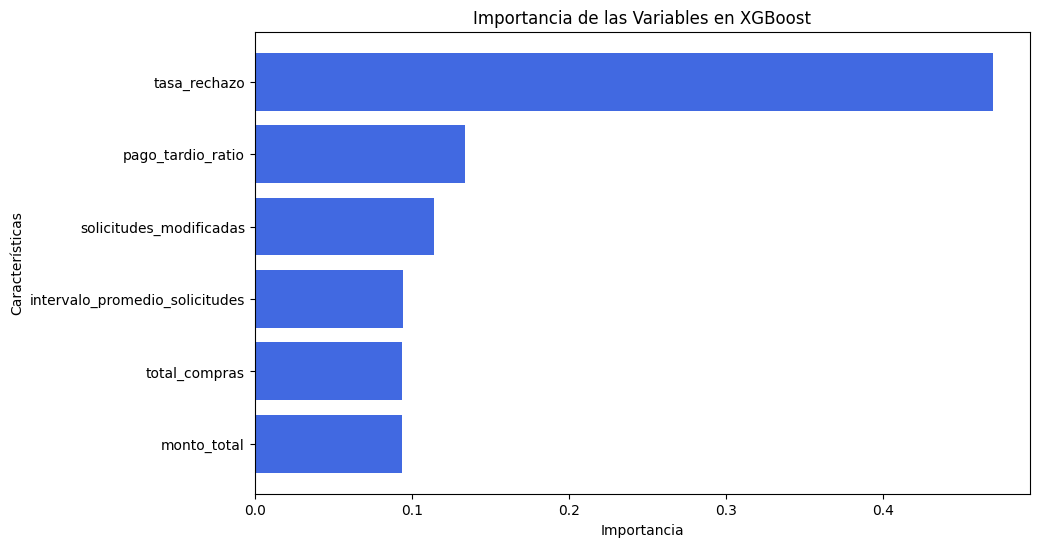

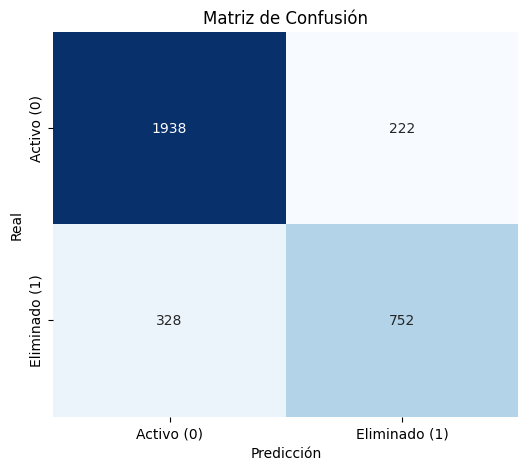

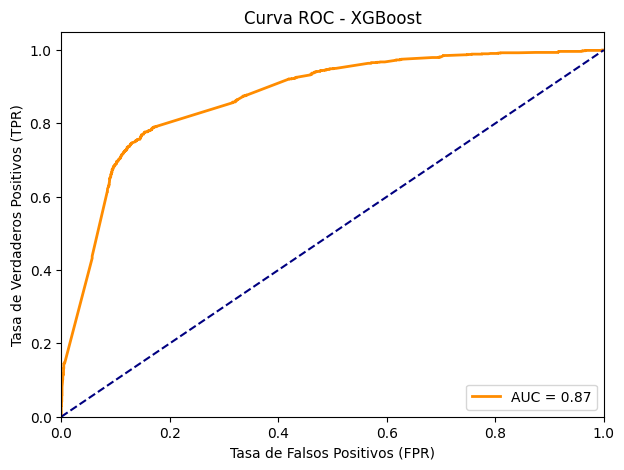

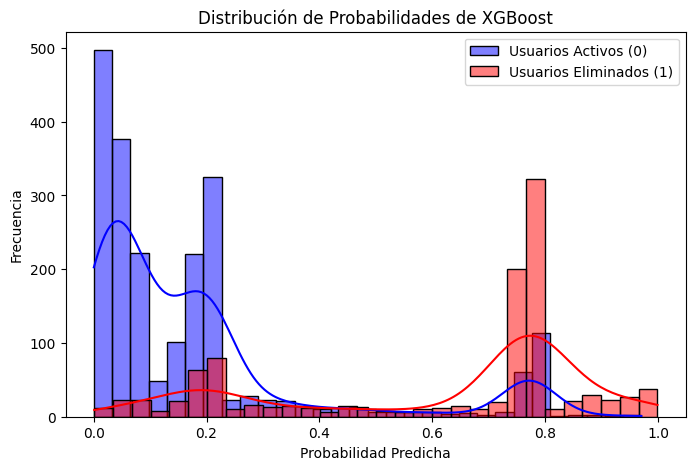

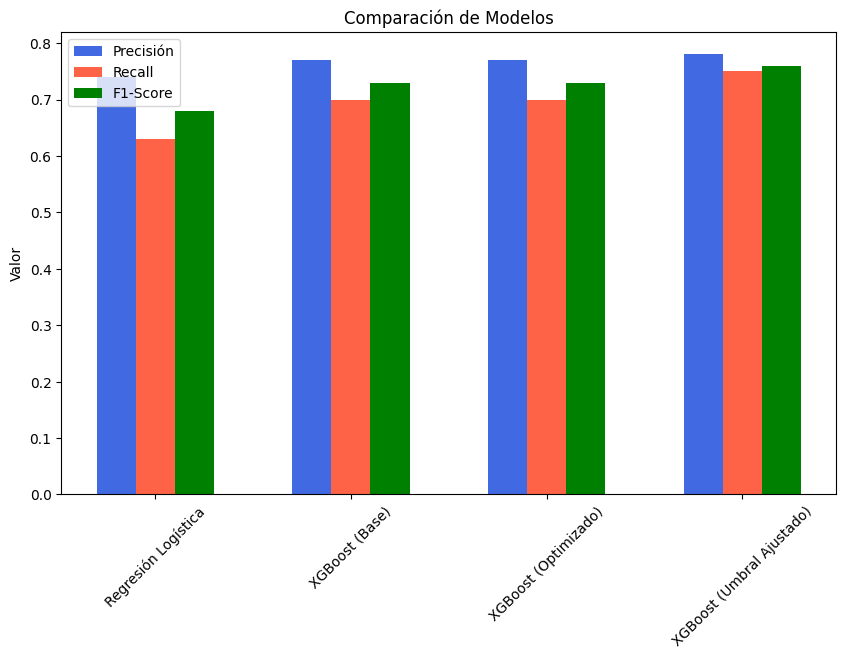

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

# 📌 1️⃣ Gráfico de Importancia de Variables
def plot_feature_importance(model, features):
    importance = model.feature_importances_
    sorted_idx = np.argsort(importance)

    plt.figure(figsize=(10, 6))
    plt.barh(np.array(features)[sorted_idx], importance[sorted_idx], color='royalblue')
    plt.xlabel("Importancia")
    plt.ylabel("Características")
    plt.title("Importancia de las Variables en XGBoost")
    plt.show()

# 📌 2️⃣ Gráfico de Matriz de Confusión
def plot_confusion_matrix(conf_matrix):
    plt.figure(figsize=(6, 5))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Activo (0)", "Eliminado (1)"],
                yticklabels=["Activo (0)", "Eliminado (1)"], cbar=False)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de Confusión")
    plt.show()

# 📌 3️⃣ Gráfico de Curva ROC y AUC
def plot_roc_curve(y_test, y_pred_prob):
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
    plt.title('Curva ROC - XGBoost')
    plt.legend(loc="lower right")
    plt.show()

# 📌 4️⃣ Gráfico de Distribución de Probabilidades
def plot_prob_distribution(y_pred_prob, y_test):
    plt.figure(figsize=(8, 5))
    sns.histplot(y_pred_prob[y_test == 0], bins=30, color="blue", label="Usuarios Activos (0)", kde=True, alpha=0.5)
    sns.histplot(y_pred_prob[y_test == 1], bins=30, color="red", label="Usuarios Eliminados (1)", kde=True, alpha=0.5)
    plt.xlabel("Probabilidad Predicha")
    plt.ylabel("Frecuencia")
    plt.title("Distribución de Probabilidades de XGBoost")
    plt.legend()
    plt.show()

# 📌 5️⃣ Comparación de Modelos (Precisión, Recall y F1-Score)
def plot_model_comparison(metrics_dict):
    labels = list(metrics_dict.keys())
    precision = [metrics_dict[model]["precision"] for model in labels]
    recall = [metrics_dict[model]["recall"] for model in labels]
    f1_score = [metrics_dict[model]["f1_score"] for model in labels]

    x = np.arange(len(labels))

    plt.figure(figsize=(10, 6))
    plt.bar(x - 0.2, precision, 0.2, label="Precisión", color="royalblue")
    plt.bar(x, recall, 0.2, label="Recall", color="tomato")
    plt.bar(x + 0.2, f1_score, 0.2, label="F1-Score", color="green")

    plt.xticks(x, labels, rotation=45)
    plt.ylabel("Valor")
    plt.title("Comparación de Modelos")
    plt.legend()
    plt.show()

# 📌 6️⃣ Ejecutar las Funciones de Visualización
print("Mostrando Gráficos de Evaluación del Modelo XGBoost...")

# Importancia de Variables
plot_feature_importance(best_xgb_model, features_xgb)

# Matriz de Confusión
plot_confusion_matrix(conf_matrix_xgb)

# Curva ROC
plot_roc_curve(y_test_xgb, y_pred_prob_xgb)

# Distribución de Probabilidades
plot_prob_distribution(y_pred_prob_xgb, y_test_xgb)

# Comparación de Modelos (Valores obtenidos manualmente del reporte de clasificación)
metrics_dict = {
    "Regresión Logística": {"precision": 0.74, "recall": 0.63, "f1_score": 0.68},
    "XGBoost (Base)": {"precision": 0.77, "recall": 0.70, "f1_score": 0.73},
    "XGBoost (Optimizado)": {"precision": 0.77, "recall": 0.70, "f1_score": 0.73},
    "XGBoost (Umbral Ajustado)": {"precision": 0.78, "recall": 0.75, "f1_score": 0.76}
}

# Comparación de Modelos
plot_model_comparison(metrics_dict)
